In [1]:
import pandas as pd
import importlib

from UniversoActivos import UniversoActivosEstatico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
import Modelos
Modelos = importlib.reload(Modelos)
from Estrategia import EstrategiaMarkI, EstrategiaMLEquiponderada, EstrategiaMLMinVarAlphaTilt
from Backtest import BacktestEngine

RandomForestModel = Modelos.RandomForestModel
XGBoostModel = Modelos.XGBoostModel

# EURO STOXX 50

In [2]:
import pandas as pd
import requests

def get_eurostoxx50_tickers():
    url = 'https://en.wikipedia.org/wiki/EURO_STOXX_50'
    
    # Añadimos una cabecera para simular un navegador real
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }
    
    # Hacemos la petición con requests
    response = requests.get(url, headers=headers)
    
    # Pasamos el contenido HTML (response.text) a pandas
    tables = pd.read_html(response.text)
    
    # Buscamos la tabla que contiene la columna 'Ticker'
    df = next(table for table in tables if 'Ticker' in table.columns)
    
    return df['Ticker'].tolist()

# Ahora ya no debería dar error
tickers = get_eurostoxx50_tickers()
print(f"Total empresas: {len(tickers)}")
print(f"Muestra: {tickers[:5]}")

Total empresas: 50
Muestra: ['ADS.DE', 'ADYEN.AS', 'AD.AS', 'AI.PA', 'AIR.PA']


C:\Users\jpuerta\AppData\Local\Temp\ipykernel_28632\2238497255.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


## XGBoost + EstrategiaMLEquiponderada

[*********************100%***********************]  50 of 50 completed
[*********************100%***********************]  50 of 50 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:48: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(Precio_Close=("Precio_Close", "last"), Volumen_USD=("Volumen_USD", "sum")).reset_index()


Modelo entrenado en fecha 2021-01-06
Modelo entrenado en fecha 2021-07-07
Modelo entrenado en fecha 2022-01-05
Modelo entrenado en fecha 2022-07-06
Modelo entrenado en fecha 2023-01-04
Modelo entrenado en fecha 2023-07-05
Modelo entrenado en fecha 2024-01-03
Modelo entrenado en fecha 2024-07-03
Modelo entrenado en fecha 2025-01-01
Modelo entrenado en fecha 2025-07-02
Modelo entrenado en fecha 2025-12-31


[*********************100%***********************]  1 of 1 completed


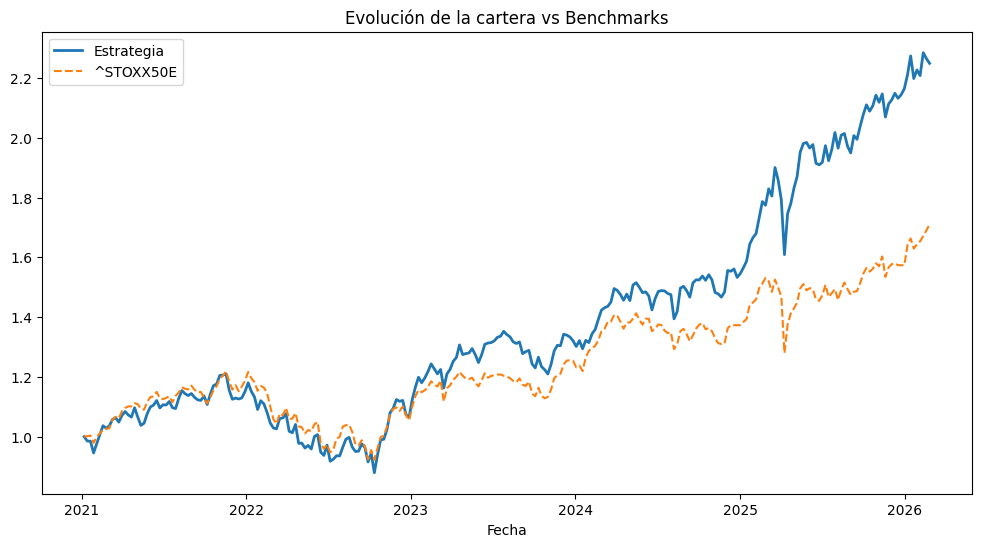

,Estrategia,^STOXX50E
Rentabilidad total,124.89%,70.95%
Rentabilidad anualizada,17.03%,10.96%
Volatilidad anualizada,17.52%,14.83%
Sharpe,0.99,0.78
Sortino,1.48,1.08
Max Drawdown,-27.31%,-24.30%
Calmar,0.62,0.45
Win rate,57.46%,58.96%
Mejor periodo,8.55%,7.45%
Peor periodo,-10.24%,-12.85%


In [3]:
universo = UniversoActivosEstatico(tickers=tickers)
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=5, ticker_indice="SPY")
modelo = XGBoostModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=10, umbral_salida=15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date="2021-01-01",
    end_date="2026-03-01",
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmks=["^STOXX50E"])

## XGBoost + EstrategiaMarkI

In [4]:
# modelo = XGBoostModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)
# estrategia = EstrategiaMarkI(modelo=modelo, n_activos_obj=10, umbral_salida=15)
# engine = BacktestEngine(
#     universo=universo,
#     proveedor=proveedor,
#     feature_engineer=fe,
#     estrategia=estrategia,
#     start_date="2021-01-01",
#     end_date="2026-03-01",
#     len_ventana=4,
#     nominal=10000000
# )

# engine.print_results(bmks=["^STOXX50E"])

## Random Forest + EstrategiaMLEquiponderada

[*********************100%***********************]  50 of 50 completed
[*********************100%***********************]  50 of 50 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:48: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(Precio_Close=("Precio_Close", "last"), Volumen_USD=("Volumen_USD", "sum")).reset_index()


Modelo entrenado en fecha 2021-01-06
Modelo entrenado en fecha 2021-07-07
Modelo entrenado en fecha 2022-01-05
Modelo entrenado en fecha 2022-07-06
Modelo entrenado en fecha 2023-01-04
Modelo entrenado en fecha 2023-07-05
Modelo entrenado en fecha 2024-01-03
Modelo entrenado en fecha 2024-07-03
Modelo entrenado en fecha 2025-01-01
Modelo entrenado en fecha 2025-07-02
Modelo entrenado en fecha 2025-12-31


[*********************100%***********************]  1 of 1 completed


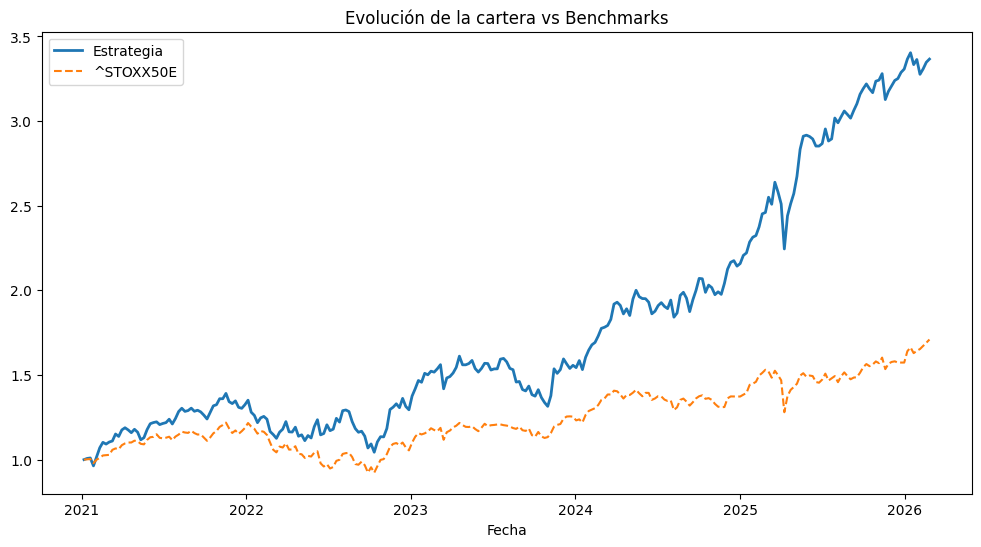

,Estrategia,^STOXX50E
Rentabilidad total,236.63%,70.95%
Rentabilidad anualizada,26.56%,10.96%
Volatilidad anualizada,20.75%,14.83%
Sharpe,1.24,0.78
Sortino,1.97,1.08
Max Drawdown,-24.97%,-24.30%
Calmar,1.06,0.45
Win rate,60.07%,58.96%
Mejor periodo,11.52%,7.45%
Peor periodo,-10.58%,-12.85%


In [5]:
modelo = RandomForestModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=10, umbral_salida=15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date="2021-01-01",
    end_date="2026-03-01",
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmks=["^STOXX50E"])

## Random Forest + EstrategiaMLMinVarAlphaTilt

[*********************100%***********************]  50 of 50 completed
[*********************100%***********************]  50 of 50 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:48: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(Precio_Close=("Precio_Close", "last"), Volumen_USD=("Volumen_USD", "sum")).reset_index()


Modelo entrenado en fecha 2021-01-06
Modelo entrenado en fecha 2021-07-07
Modelo entrenado en fecha 2022-01-05
Modelo entrenado en fecha 2022-07-06
Modelo entrenado en fecha 2023-01-04
Modelo entrenado en fecha 2023-07-05
Modelo entrenado en fecha 2024-01-03
Modelo entrenado en fecha 2024-07-03
Modelo entrenado en fecha 2025-01-01
Modelo entrenado en fecha 2025-07-02
Modelo entrenado en fecha 2025-12-31


[*********************100%***********************]  1 of 1 completed


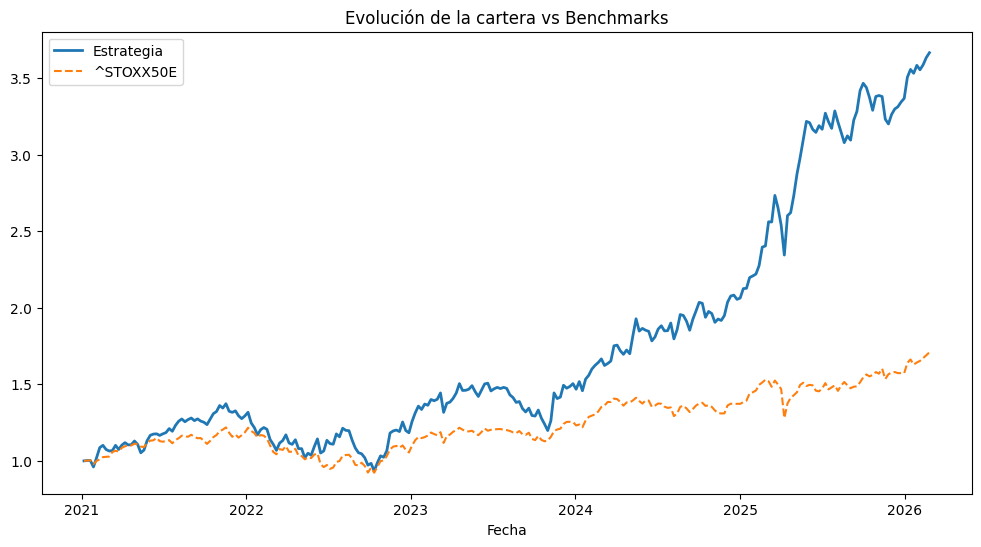

,Estrategia,^STOXX50E
Rentabilidad total,266.73%,70.95%
Rentabilidad anualizada,28.68%,10.96%
Volatilidad anualizada,23.08%,14.83%
Sharpe,1.21,0.78
Sortino,2.04,1.08
Max Drawdown,-32.00%,-24.30%
Calmar,0.90,0.45
Win rate,57.46%,58.96%
Mejor periodo,14.36%,7.45%
Peor periodo,-8.77%,-12.85%


In [6]:
modelo = RandomForestModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)

estrategia = EstrategiaMLMinVarAlphaTilt(
    modelo=modelo,
    n_activos_obj=10,
    umbral_salida=15,      # universo candidato para optimización
    p_neutral=0.55,        # más conservador que 0.50
    alpha_scale=1.0,
    lambda_risk=3.0,       # subir para bajar volatilidad
    lambda_tc=0.001,       # subir para rotar menos
    w_max=0.15,
    turnover_max=0.20,
    no_trade_band=0.002,   # 40 bps de banda
    coste_transaccion=0.0005,  # 5 bps
    utility_buffer=0.0001,     # histéresis adicional
    min_hist_obs=26
)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date="2021-01-01",
    end_date="2026-03-01",
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmks=["^STOXX50E"])

## XGBoostModel + EstrategiaMLMinVarAlphaTilt

[*********************100%***********************]  50 of 50 completed
[*********************100%***********************]  50 of 50 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:48: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(Precio_Close=("Precio_Close", "last"), Volumen_USD=("Volumen_USD", "sum")).reset_index()


Modelo entrenado en fecha 2021-01-06
Modelo entrenado en fecha 2021-07-07
Modelo entrenado en fecha 2022-01-05
Modelo entrenado en fecha 2022-07-06
Modelo entrenado en fecha 2023-01-04
Modelo entrenado en fecha 2023-07-05
Modelo entrenado en fecha 2024-01-03
Modelo entrenado en fecha 2024-07-03
Modelo entrenado en fecha 2025-01-01
Modelo entrenado en fecha 2025-07-02
Modelo entrenado en fecha 2025-12-31


[*********************100%***********************]  1 of 1 completed


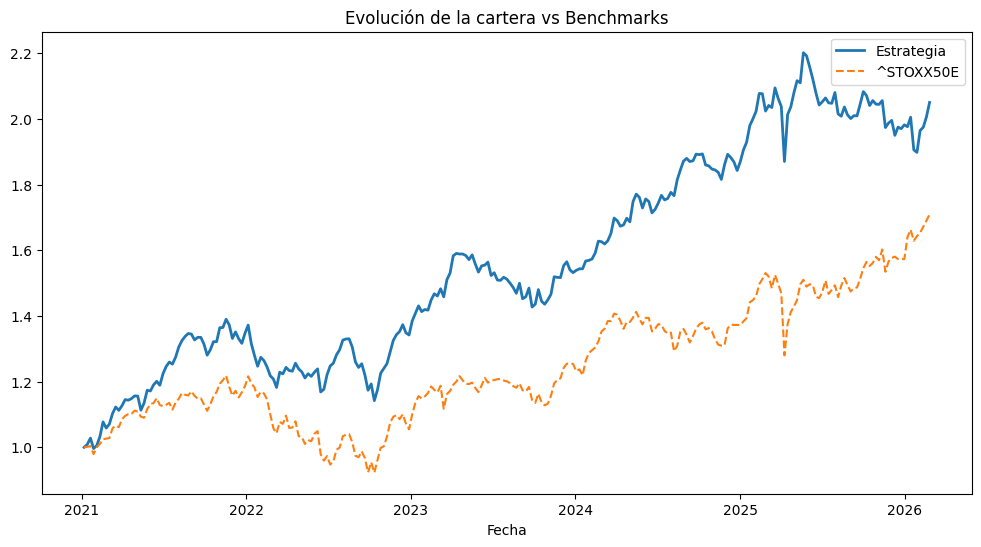

,Estrategia,^STOXX50E
Rentabilidad total,105.06%,70.95%
Rentabilidad anualizada,14.95%,10.96%
Volatilidad anualizada,13.64%,14.83%
Sharpe,1.09,0.78
Sortino,1.64,1.08
Max Drawdown,-17.83%,-24.30%
Calmar,0.84,0.45
Win rate,56.72%,58.96%
Mejor periodo,7.64%,7.45%
Peor periodo,-8.21%,-12.85%


In [7]:
modelo = XGBoostModel(
    n_estimators=300,
    max_depth=4,
    positive_class_weight=8.0
)

estrategia = EstrategiaMLMinVarAlphaTilt(
    modelo=modelo,
    n_activos_obj=10,
    umbral_salida=15,      # universo candidato para optimización
    p_neutral=0.55,        # más conservador que 0.50
    alpha_scale=1.0,
    lambda_risk=3.0,       # subir para bajar volatilidad
    lambda_tc=0.001,       # subir para rotar menos
    w_max=0.15,
    turnover_max=0.20,
    no_trade_band=0.002,   # 40 bps de banda
    coste_transaccion=0.0005,  # 5 bps
    utility_buffer=0.0001,     # histéresis adicional
    min_hist_obs=26
)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date="2021-01-01",
    end_date="2026-03-01",
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmks=["^STOXX50E"])

# Cartera de ETFs por sectores

In [8]:
csv_path = r"pipelineJC\data\etfs_by_sector_industry_commodity.csv"

df = pd.read_csv(csv_path)
tickers = df["Ticker"].dropna().astype(str).str.strip().unique().tolist()

## XGBoost + EstrategiaMLEquiponderada

[*********************100%***********************]  40 of 40 completed
[*********************100%***********************]  40 of 40 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:48: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(Precio_Close=("Precio_Close", "last"), Volumen_USD=("Volumen_USD", "sum")).reset_index()


Modelo entrenado en fecha 2021-01-06
Modelo entrenado en fecha 2021-07-07
Modelo entrenado en fecha 2022-01-05
Modelo entrenado en fecha 2022-07-06
Modelo entrenado en fecha 2023-01-04
Modelo entrenado en fecha 2023-07-05
Modelo entrenado en fecha 2024-01-03
Modelo entrenado en fecha 2024-07-03
Modelo entrenado en fecha 2025-01-01
Modelo entrenado en fecha 2025-07-02
Modelo entrenado en fecha 2025-12-31


[*********************100%***********************]  40 of 40 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Backtest.py:189: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  serie_ew = (1 + precios.pct_change().mean(axis=1, skipna=True).fillna(0)).cumprod()


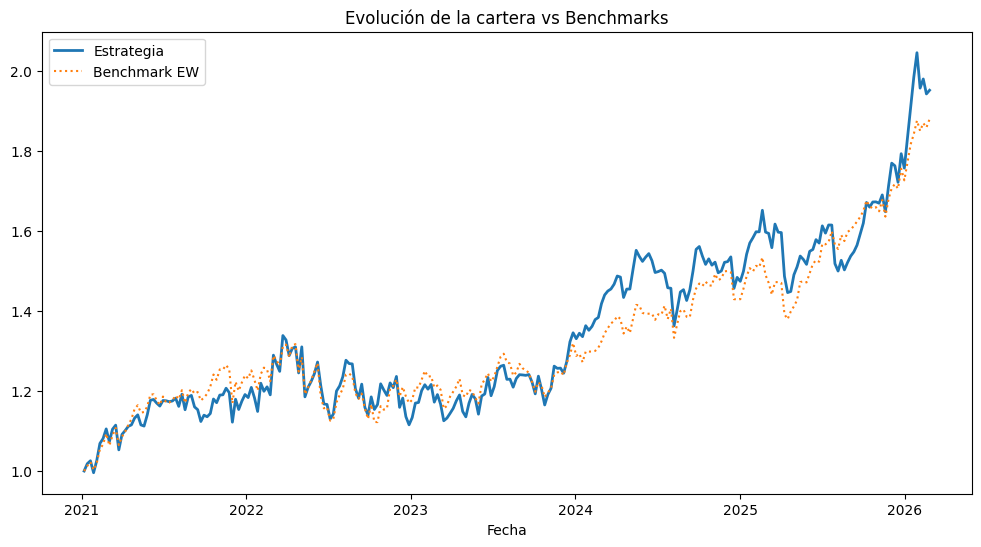

,Estrategia,Benchmark EW
Rentabilidad total,95.26%,88.02%
Rentabilidad anualizada,13.86%,13.03%
Volatilidad anualizada,18.20%,14.13%
Sharpe,0.81,0.94
Sortino,1.17,1.32
Max Drawdown,-16.68%,-14.81%
Calmar,0.83,0.88
Win rate,58.96%,59.33%
Mejor periodo,8.33%,5.25%
Peor periodo,-9.54%,-7.25%


In [9]:
universo = UniversoActivosEstatico(tickers=tickers)
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=5, ticker_indice="SPY")
modelo = XGBoostModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=10, umbral_salida=15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date="2021-01-01",
    end_date="2026-03-01",
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmk_equal_weight=tickers)

## XGBoost + EstrategiaMarkI

In [10]:
# modelo = XGBoostModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)
# estrategia = EstrategiaMarkI(modelo=modelo, n_activos_obj=10, umbral_salida=15)
# engine = BacktestEngine(
#     universo=universo,
#     proveedor=proveedor,
#     feature_engineer=fe,
#     estrategia=estrategia,
#     start_date="2021-01-01",
#     end_date="2026-03-01",
#     len_ventana=4,
#     nominal=10000000
# )

# engine.print_results(bmks=["^STOXX50E"])

## RandomForestModel + EstrategiaMLEquiponderada

[*********************100%***********************]  40 of 40 completed
[*********************100%***********************]  40 of 40 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:48: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(Precio_Close=("Precio_Close", "last"), Volumen_USD=("Volumen_USD", "sum")).reset_index()


Modelo entrenado en fecha 2021-01-06
Modelo entrenado en fecha 2021-07-07
Modelo entrenado en fecha 2022-01-05
Modelo entrenado en fecha 2022-07-06
Modelo entrenado en fecha 2023-01-04
Modelo entrenado en fecha 2023-07-05
Modelo entrenado en fecha 2024-01-03
Modelo entrenado en fecha 2024-07-03
Modelo entrenado en fecha 2025-01-01
Modelo entrenado en fecha 2025-07-02
Modelo entrenado en fecha 2025-12-31


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  40 of 40 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Backtest.py:189: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  serie_ew = (1 + precios.pct_change().mean(axis=1, skipna=True).fillna(0)).cumprod()


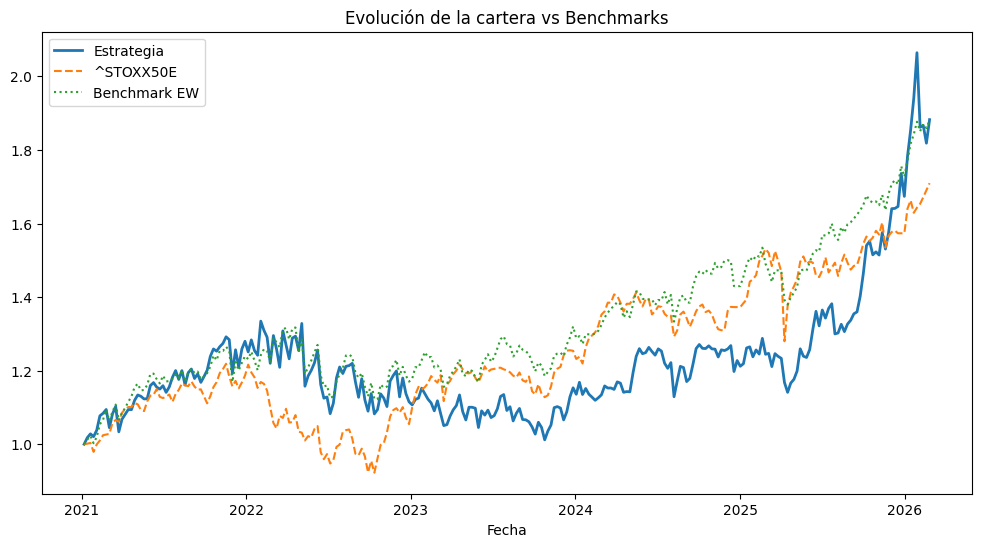

,Estrategia,^STOXX50E,Benchmark EW
Rentabilidad total,88.24%,70.95%,88.02%
Rentabilidad anualizada,13.06%,10.96%,13.03%
Volatilidad anualizada,21.43%,14.83%,14.13%
Sharpe,0.68,0.78,0.94
Sortino,0.98,1.08,1.32
Max Drawdown,-24.17%,-24.30%,-14.81%
Calmar,0.54,0.45,0.88
Win rate,57.09%,58.96%,59.33%
Mejor periodo,8.20%,7.45%,5.25%
Peor periodo,-12.84%,-12.85%,-7.25%


In [11]:
modelo = RandomForestModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=10, umbral_salida=15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date="2021-01-01",
    end_date="2026-03-01",
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmks=["^STOXX50E"], bmk_equal_weight=tickers)

## Random Forest + EstrategiaMLMinVarAlphaTilt

In [13]:
modelo = RandomForestModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)

estrategia = EstrategiaMLMinVarAlphaTilt(
    modelo=modelo,
    n_activos_obj=10,
    umbral_salida=15,      # universo candidato para optimización
    p_neutral=0.55,        # más conservador que 0.50
    alpha_scale=1.0,
    lambda_risk=3.0,       # subir para bajar volatilidad
    lambda_tc=0.001,       # subir para rotar menos
    w_max=0.15,
    turnover_max=0.20,
    no_trade_band=0.002,   # 40 bps de banda
    coste_transaccion=0.0005,  # 5 bps
    utility_buffer=0.0001,     # histéresis adicional
    min_hist_obs=26
)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date="2021-01-01",
    end_date="2026-03-01",
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmks=["^STOXX50E"], bmk_equal_weight=tickers)

[*********************100%***********************]  40 of 40 completed
[*********************100%***********************]  40 of 40 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:48: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(Precio_Close=("Precio_Close", "last"), Volumen_USD=("Volumen_USD", "sum")).reset_index()


Modelo entrenado en fecha 2021-01-06
Modelo entrenado en fecha 2021-07-07
Modelo entrenado en fecha 2022-01-05
Modelo entrenado en fecha 2022-07-06
Modelo entrenado en fecha 2023-01-04
Modelo entrenado en fecha 2023-07-05


ValueError: cannot convert float NaN to integer

## XGBoostModel + EstrategiaMLMinVarAlphaTilt

In [ ]:
modelo = XGBoostModel(
    n_estimators=300,
    max_depth=4,
    positive_class_weight=8.0
)

estrategia = EstrategiaMLMinVarAlphaTilt(
    modelo=modelo,
    n_activos_obj=10,
    umbral_salida=15,      # universo candidato para optimización
    p_neutral=0.55,        # más conservador que 0.50
    alpha_scale=1.0,
    lambda_risk=3.0,       # subir para bajar volatilidad
    lambda_tc=0.001,       # subir para rotar menos
    w_max=0.15,
    turnover_max=0.20,
    no_trade_band=0.002,   # 40 bps de banda
    coste_transaccion=0.0005,  # 5 bps
    utility_buffer=0.0001,     # histéresis adicional
    min_hist_obs=26
)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date="2021-01-01",
    end_date="2026-03-01",
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmks=["^STOXX50E"])